In [1]:
import numpy as np
import pandas as pd

In [8]:
df=pd.read_csv('titanic.csv')

In [9]:
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [10]:
df['number'].unique()

array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

Text(0.5, 1.0, 'passengers travelling with')

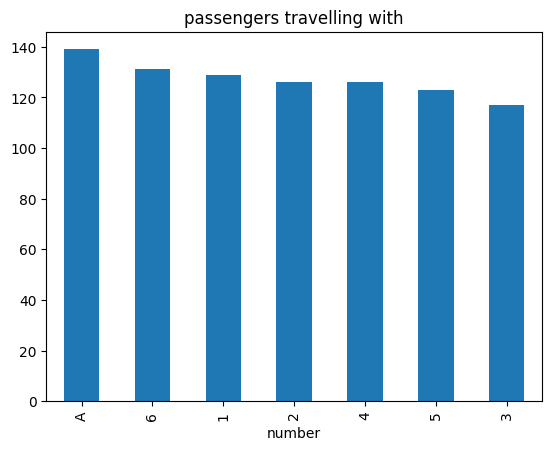

In [11]:
fig=df['number'].value_counts().plot.bar()
fig.set_title('passengers travelling with')

In [12]:
#extract numerical part
df['number_numerical']=pd.to_numeric(df['number'],errors='coerce',downcast='integer')


In [14]:
#extract categorical part
df['number_catrgorical']=np.where(df['number_numerical'].isnull(),df['number'],np.nan)
df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_catrgorical
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [17]:
df['Cabin'].nunique()

147

In [18]:
df['Ticket'].nunique()

681

In [20]:
df['cabin_num']=df['Cabin'].str.extract('(\d+)') # captures numerical part
df['cabin_cat']=df['Cabin'].str[0]  #captures the first letter

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/hf/6lfxg80j4dd60259tn0rq5380000gn/T/ipykernel_4824/1639658406.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['cabin_num']=df['Cabin'].str.extract('(\d+)') # captures numerical part


In [21]:
df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_catrgorical,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


<Axes: xlabel='cabin_cat'>

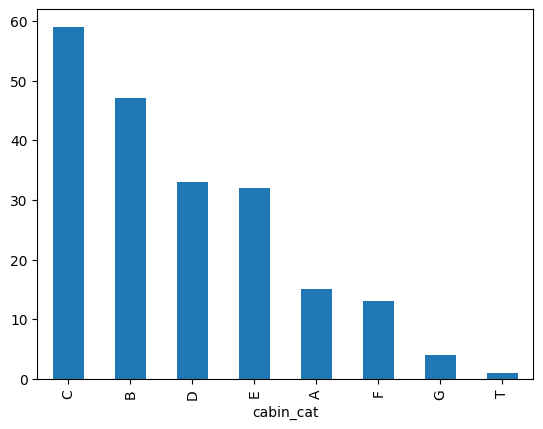

In [22]:
df['cabin_cat'].value_counts().plot(kind='bar')

In [26]:
#extract the last bit of ticket as number
df['ticket_num']=df['Ticket'].apply(lambda s:s.split()[-1])
df['ticket_num']=pd.to_numeric(df['ticket_num'],errors='coerce',downcast='integer')
# extract the first part of ticket as category
df['ticket_cat']=df['Ticket'].apply(lambda s:s.split()[0])
df['ticket_cat']=np.where(df['ticket_cat'].str.isdigit(),np.nan,df['ticket_cat'])

In [27]:
df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_catrgorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN
